#Ejercicio 1: Peaje con colas multicanal (no Poisson)
🎯 Objetivo

Simular el funcionamiento de un peaje con 4 cabinas donde los autos no llegan al azar (no Poisson), sino en “pelotones” por efecto de un semáforo anterior. Analizar cómo cambia el desempeño respecto de un modelo teórico M/M/4.

📋 Consigna

1. Simular la llegada de 1000 autos.

2. Los tiempos entre llegadas siguen una distribución Weibull(k = 2, media = 2,5 s).

3. Los tiempos de servicio siguen una distribución Gamma(k = 2, media = 8 s).

4. Hay 4 cabinas de cobro (servidores) que trabajan en paralelo.

5. Calcular y graficar:

- Tiempo medio de espera en cola E[Wq].

- Longitud media de cola E[Lq].

- Utilización promedio por cabina ρ.

6. Estimar el coeficiente de variación (CV²) de llegadas y servicios

7. Interpretar los resultados: ¿el sistema es estable? ¿qué pasaría si las llegadas fueran más irregulares (Weibull k < 1.5)?

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [37]:
# Parámetros ajustados
n_autos = 1000
c = 4  # cabinas
media_llegada = 2.5
media_servicio = 8
k_weibull = 2
k_gamma = 2

In [38]:
# --- Función para generar tiempos entre llegadas (Weibull) ---
def weibull_custom(n, k, media_deseada):
    """
    Genera n muestras Weibull con forma k y media igual a media_deseada.
    Retorna las muestras y el coeficiente de variación al cuadrado (CV²).
    """
    # Ajuste de escala para lograr la media deseada
    escala = media_deseada / math.gamma(1 + 1/k)
    muestras = np.random.weibull(k, n) * escala

    # Calcular media, desviación y CV² teórico aproximado
    media = np.mean(muestras)
    desvio = np.std(muestras)
    cv2 = (desvio / media) ** 2

    print(f"[Weibull] Media: {media:.2f} | Desvío: {desvio:.2f} | CV²: {cv2:.2f}")
    return muestras

In [39]:
# --- Función para generar tiempos de servicio (Gamma) ---
def gamma_custom(n, k, media_deseada):
    """
    Genera n muestras Gamma con forma k y media igual a media_deseada.
    Retorna las muestras y el coeficiente de variación al cuadrado (CV²).
    """
    theta = media_deseada / k
    muestras = np.random.gamma(k, theta, n)

    media = np.mean(muestras)
    desvio = np.std(muestras)
    cv2 = (desvio / media) ** 2

    print(f"[Gamma] Media: {media:.2f} | Desvío: {desvio:.2f} | CV²: {cv2:.2f}")
    return muestras

In [40]:
# Generar llegadas y servicios
llegadas = weibull_custom(n_autos, k_weibull, media_llegada)
servicios = gamma_custom(n_autos, k_gamma, media_servicio)
tiempos_llegada = np.cumsum(llegadas)

[Weibull] Media: 2.53 | Desvío: 1.31 | CV²: 0.27
[Gamma] Media: 7.90 | Desvío: 5.55 | CV²: 0.49


In [41]:
# --- Simulación ---
tiempo_serv_fin = [0]*c
esperas = []

for i in range(n_autos):
    t_llegada = tiempos_llegada[i]
    idx_libre = np.argmin(tiempo_serv_fin)
    t_libre = tiempo_serv_fin[idx_libre]

    if t_llegada < t_libre:
        espera = t_libre - t_llegada
        esperas.append(espera)
        tiempo_serv_fin[idx_libre] += servicios[i]
    else:
        esperas.append(0)
        tiempo_serv_fin[idx_libre] = t_llegada + servicios[i]


In [42]:
# --- Métricas ---
Wq_prom = np.mean(esperas)
rho = np.mean(servicios) / (np.mean(llegadas) * c)
Lq_prom = Wq_prom / np.mean(servicios)

print(f"Tiempo medio de espera en cola: {Wq_prom:.2f} s")
print(f"Longitud media de cola: {Lq_prom:.2f} autos")
print(f"Utilización promedio por cabina: {rho:.2f}")


Tiempo medio de espera en cola: 1.14 s
Longitud media de cola: 0.14 autos
Utilización promedio por cabina: 0.78


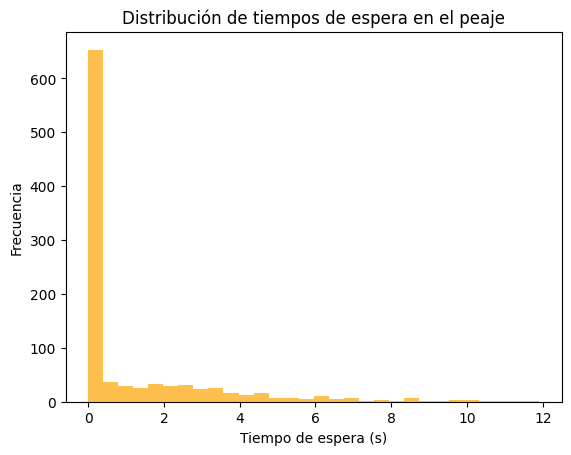

In [43]:
plt.hist(esperas, bins=30, color='orange', alpha=0.7)
plt.title("Distribución de tiempos de espera en el peaje")
plt.xlabel("Tiempo de espera (s)")
plt.ylabel("Frecuencia")
plt.show()

/tmp/ipython-input-3336644359.py:4: RuntimeWarning: divide by zero encountered in power
  y = (k / escala) * (x / escala)**(k-1) * np.exp(-(x/escala)**k)


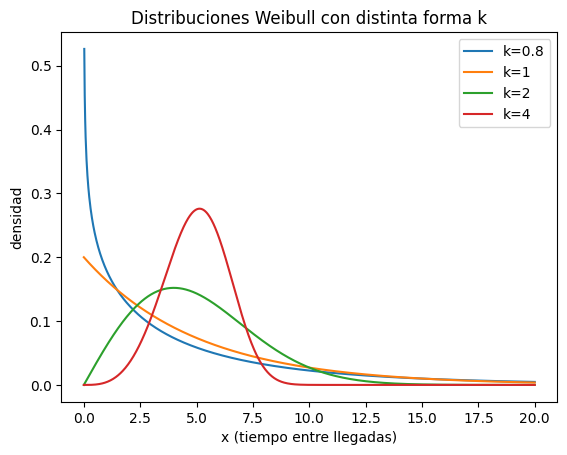

In [44]:
x = np.linspace(0, 20, 1000)
for k in [0.8, 1, 2, 4]:
    escala = 5 / math.gamma(1 + 1/k)
    y = (k / escala) * (x / escala)**(k-1) * np.exp(-(x/escala)**k)
    plt.plot(x, y, label=f"k={k}")
plt.title("Distribuciones Weibull con distinta forma k")
plt.xlabel("x (tiempo entre llegadas)")
plt.ylabel("densidad")
plt.legend()
plt.show()

# Ejercicio 2: Call Center multicanal (no Poisson)
🎯 Objetivo

Simular un call center con varios operadores donde las llamadas llegan en ráfagas y los tiempos de atención son irregulares. Mostrar cómo la variabilidad afecta el desempeño.

📋 Consigna

1. Simular 500 llamadas a un call center con 3 operadores.

2. Los intervalos entre llamadas siguen una distribución Gamma(k = 1.5, media = 40 s) (arribos agrupados).

3. Los tiempos de atención siguen una distribución Lognormal(μ = 3.5, σ = 0.3) (atenciones variables).

4. Calcular:

- Tiempo medio de espera E[Wq].

- Ocupación promedio ρ.

- Porcentaje de llamadas que esperan más de 1 minuto.

5. Estimar el coeficiente de variación (CV²) de llegadas y servicios

6. Graficar la evolución temporal del número de llamadas en el sistema.

In [45]:
import numpy as np
import matplotlib.pyplot as plt

In [46]:
# --- Parámetros ---
n_llamadas = 500
c = 3
media_llegada = 40
k_gamma_llegada = 1.5

# Lognormal: parámetros
mu_ln, sigma_ln = 3.5, 0.3  # log-espacio
media_servicio = np.exp(mu_ln + (sigma_ln**2)/2)

In [47]:
# Importamos las librerías necesarias
import numpy as np
import math
from scipy.stats import gamma

# --- Función para generar tiempos entre llegadas (Gamma) ---
def gamma_custom_llegadas(n, k, media_deseada):
    """
    Genera n muestras Gamma con parámetro de forma 'k' y media
    igual a 'media_deseada'.
    Retorna las muestras y el coeficiente de variación al cuadrado (CV²).
    """
    # Para la distribución Gamma, la media es k * theta (parámetro de escala).
    # Por lo tanto, theta = media_deseada / k
    theta_escala = media_deseada / k

    # Generar muestras Gamma(forma=k, escala=theta)
    # En SciPy, 'a' es el parámetro de forma (k) y 'scale' es el parámetro de escala (theta).
    muestras = gamma.rvs(a=k, scale=theta_escala, size=n)

    # Calcular media, desviación y CV²
    media = np.mean(muestras)
    desvio = np.std(muestras)
    cv2 = (desvio / media) ** 2

    print(f"[Gamma - Llegadas] Media simulada: {media:.2f} | Desvío: {desvio:.2f} | CV² simulado: {cv2:.2f}")

    # El CV² teórico de una distribución Gamma con parámetro de forma k es 1/k
    cv2_teorico = 1 / k
    print(f"                       CV² teórico (1/k): {cv2_teorico:.2f}")

    return muestras, cv2

# Adaptación: Guardamos el CV² para uso posterior
# Asegúrate de que las variables n_llamadas, k_gamma_llegada y media_llegada
# (definidas en bloques anteriores) hayan sido ejecutadas.
TAL, CV2_TAL = gamma_custom_llegadas(n_llamadas, k_gamma_llegada, media_llegada)

[Gamma - Llegadas] Media simulada: 37.78 | Desvío: 29.91 | CV² simulado: 0.63
                       CV² teórico (1/k): 0.67


In [48]:
# Importamos las librerías necesarias
import numpy as np
from scipy.stats import lognorm # Necesario para generar la distribución Lognormal

# --- Función para generar tiempos de servicio (Lognormal) ---
def lognormal_custom_servicio(n, mu_ln, sigma_ln):
    """
    Genera n muestras Lognormal utilizando los parámetros mu (location=0,
    parámetro 's' en SciPy) y sigma (escala) en el log-espacio.
    Retorna las muestras y el coeficiente de variación al cuadrado (CV²).
    """
    # En SciPy:
    # 's' es el parámetro sigma (sigma_ln)
    # 'scale' es exp(mu) (exp(mu_ln))

    # Generar muestras Lognormal
    muestras = lognorm.rvs(s=sigma_ln, scale=np.exp(mu_ln), size=n)

    # Calcular media, desviación y CV²
    media = np.mean(muestras)
    desvio = np.std(muestras)
    cv2 = (desvio / media) ** 2

    # El CV² teórico de una Lognormal es: exp(sigma^2) - 1
    cv2_teorico = np.exp(sigma_ln**2) - 1

    print(f"[Lognormal - Servicio] Media simulada: {media:.2f} | Desvío: {desvio:.2f} | CV² simulado: {cv2:.2f}")
    print(f"                             Media teórica: {media_servicio:.2f} | CV² teórico: {cv2_teorico:.2f}")

    return muestras, cv2

# Guardamos el CV² de servicio para uso posterior
TS, CV2_TS = lognormal_custom_servicio(n_llamadas, mu_ln, sigma_ln)

[Lognormal - Servicio] Media simulada: 34.34 | Desvío: 10.29 | CV² simulado: 0.09
                             Media teórica: 34.64 | CV² teórico: 0.09


In [49]:
# Aseguramos la importación de numpy
import numpy as np

# Generar Tiempos entre Llegadas (TAL)
llegadas, CV2_TAL = gamma_custom_llegadas(n_llamadas, k_gamma_llegada, media_llegada)

print("\n--- Generando Tiempos de Servicio ---")

# Generar Tiempos de Servicio (TS)
servicios, CV2_TS = lognormal_custom_servicio(n_llamadas, mu_ln, sigma_ln)

# Calcular los tiempos ABSOLUTOS de llegada (TA)
tiempos_llegada = np.cumsum(llegadas)

print("\n--- Resumen de variables generadas ---")
print(f"Total de llamadas simuladas: {len(llegadas)}")
print(f"Tiempo total simulado: {tiempos_llegada[-1]/60:.2f} minutos")

[Gamma - Llegadas] Media simulada: 38.38 | Desvío: 31.44 | CV² simulado: 0.67
                       CV² teórico (1/k): 0.67

--- Generando Tiempos de Servicio ---
[Lognormal - Servicio] Media simulada: 34.28 | Desvío: 10.02 | CV² simulado: 0.09
                             Media teórica: 34.64 | CV² teórico: 0.09

--- Resumen de variables generadas ---
Total de llamadas simuladas: 500
Tiempo total simulado: 319.85 minutos


In [50]:
# Importamos la librería pandas (aunque no se usa directamente en este bloque)
import pandas as pd
import numpy as np # Necesario para np.argmin

# --- Simulación del Call Center (M/G/c) ---

# tiempo_serv_fin: Tiempo en que cada operador (servidor) quedará libre.
tiempo_serv_fin = [0] * c
esperas = []
tiempo_entrada_servicio = []
tiempo_salida_sistema = []

# Bucle principal de la simulación
for i in range(n_llamadas):
    t_llegada = tiempos_llegada[i]

    # 1. Encontrar al operador que estará libre MÁS PRONTO
    idx_libre = np.argmin(tiempo_serv_fin)
    t_libre = tiempo_serv_fin[idx_libre]

    # --- Cálculo de la espera ---
    if t_llegada < t_libre:
        # La llamada debe esperar
        espera = t_libre - t_llegada
        t_comienzo_servicio = t_libre
    else:
        # No hay espera
        espera = 0
        t_comienzo_servicio = t_llegada

    # --- Actualización de registros y estado del sistema ---

    # 2. Registrar las métricas
    esperas.append(espera)
    tiempo_entrada_servicio.append(t_comienzo_servicio)

    # 3. Actualizar el tiempo en que el operador terminará el servicio
    t_salida = t_comienzo_servicio + servicios[i]
    tiempo_serv_fin[idx_libre] = t_salida
    tiempo_salida_sistema.append(t_salida)

print("--- Simulación finalizada ---")
print(f"Número de esperas registradas: {len(esperas)}")

--- Simulación finalizada ---
Número de esperas registradas: 500


In [51]:
# Importamos numpy para las operaciones
import numpy as np

# --- Cálculo de Métricas (Call Center) ---

# 1. Tiempo medio de espera en cola (E[Wq])
Wq_prom = np.mean(esperas)

# 2. Utilización promedio (Ocupación promedio, ρ)
lambda_efectiva = 1 / np.mean(llegadas)
rho = lambda_efectiva * np.mean(servicios) / c

# 3. Longitud media de cola (E[Lq]) - Ley de Little: Lq = lambda * Wq
Lq_prom = lambda_efectiva * Wq_prom

# 4. Porcentaje de llamadas que esperan más de 1 minuto (60 segundos)
esperas_array = np.array(esperas)
espera_limite_seg = 60.0
llamadas_con_espera_larga = np.sum(esperas_array > espera_limite_seg)
porcentaje_espera_larga = (llamadas_con_espera_larga / n_llamadas) * 100

# --- Presentación de Resultados ---

print("## 📊 Resultados de la Simulación del Call Center (M/G/3) ##")
print("---")
print(f"**Tiempo medio de espera en cola (E[Wq]):** {Wq_prom:.2f} s")
print(f"**Longitud media de cola (E[Lq]):** {Lq_prom:.2f} llamadas")
print(f"**Ocupación promedio por operador (ρ):** {rho:.2f}")
print(f"**% de llamadas que esperan más de 1 minuto:** {porcentaje_espera_larga:.2f} %")
print("---")
print("## Coeficientes de Variación (CV²) ##")
print(f"**CV² de Llegadas (Gamma k=1.5):** {CV2_TAL:.2f}")
print(f"**CV² de Servicio (Lognormal):** {CV2_TS:.2f}")

## 📊 Resultados de la Simulación del Call Center (M/G/3) ##
---
**Tiempo medio de espera en cola (E[Wq]):** 0.32 s
**Longitud media de cola (E[Lq]):** 0.01 llamadas
**Ocupación promedio por operador (ρ):** 0.30
**% de llamadas que esperan más de 1 minuto:** 0.00 %
---
## Coeficientes de Variación (CV²) ##
**CV² de Llegadas (Gamma k=1.5):** 0.67
**CV² de Servicio (Lognormal):** 0.09


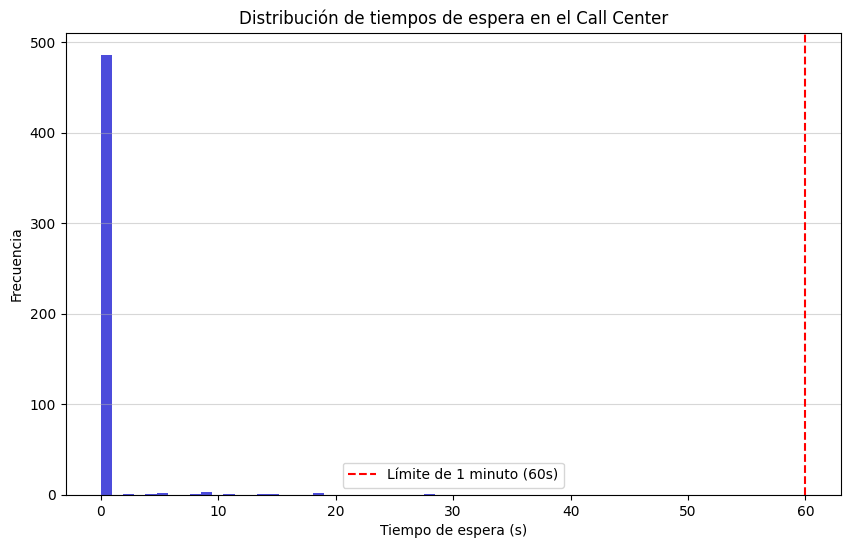

In [52]:
import matplotlib.pyplot as plt

# Histograma de Tiempos de Espera
plt.figure(figsize=(10, 6))
plt.hist(esperas, bins=30, color='mediumblue', alpha=0.7)
plt.axvline(x=60, color='red', linestyle='--', label='Límite de 1 minuto (60s)') # Marcamos el límite de tu métrica
plt.title("Distribución de tiempos de espera en el Call Center")
plt.xlabel("Tiempo de espera (s)")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

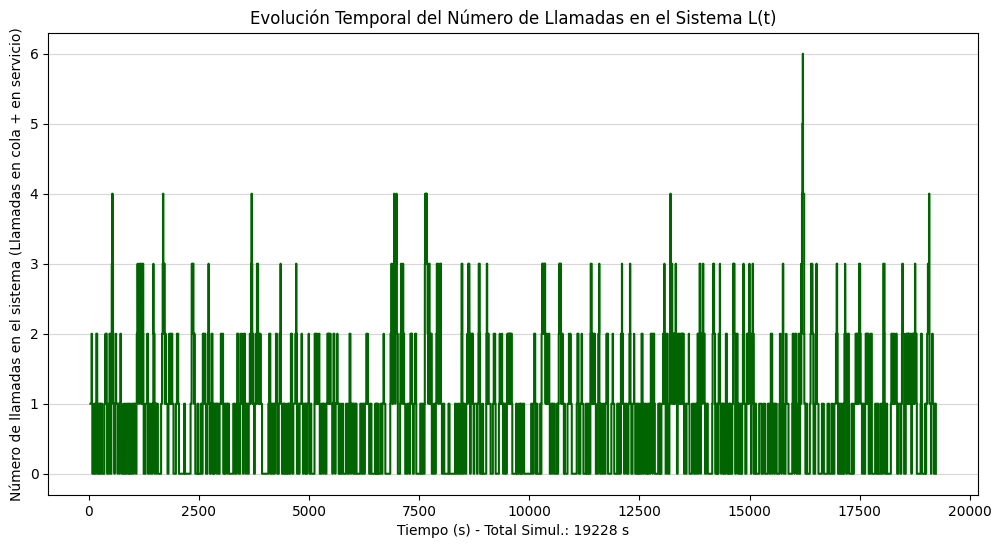

In [53]:
# --- Cálculo de la evolución temporal del sistema (L(t)) ---

# 1. Crear un DataFrame de eventos (Llegadas y Salidas)
# Un evento es la llegada (A) o la salida (D) de una llamada.
eventos = []

# Eventos de llegada (A)
for i in range(n_llamadas):
    eventos.append({'Tiempo': tiempos_llegada[i], 'Tipo': 'A', 'Cliente': i})

# Eventos de salida (D)
for i in range(n_llamadas):
    # El tiempo de salida ya se calculó en la simulación principal
    eventos.append({'Tiempo': tiempo_salida_sistema[i], 'Tipo': 'D', 'Cliente': i})

# 2. Ordenar los eventos cronológicamente
df_eventos = pd.DataFrame(eventos).sort_values(by='Tiempo').reset_index(drop=True)

# 3. Calcular la evolución del número de llamadas en el sistema
df_eventos['N_Sistema'] = 0
n_actual = 0
for index, row in df_eventos.iterrows():
    if row['Tipo'] == 'A':
        n_actual += 1
    elif row['Tipo'] == 'D':
        n_actual -= 1
    df_eventos.loc[index, 'N_Sistema'] = n_actual

# --- Graficación de la Evolución Temporal ---
plt.figure(figsize=(12, 6))
# Usamos un gráfico de escalones (step) para mostrar la evolución discreta
plt.step(df_eventos['Tiempo'], df_eventos['N_Sistema'], where='post', color='darkgreen')
plt.title("Evolución Temporal del Número de Llamadas en el Sistema L(t)")
plt.xlabel(f"Tiempo (s) - Total Simul.: {df_eventos['Tiempo'].iloc[-1]:.0f} s")
plt.ylabel("Número de llamadas en el sistema (Llamadas en cola + en servicio)")
plt.grid(axis='y', alpha=0.5)
plt.show()

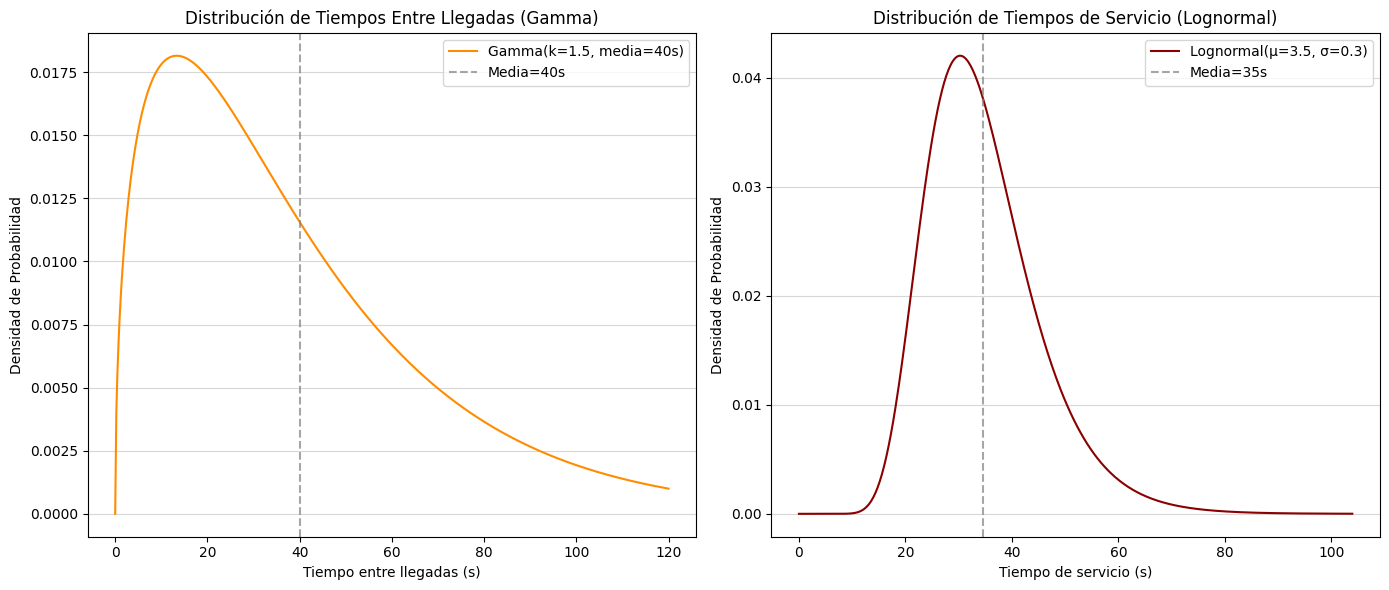

In [54]:
from scipy.stats import gamma, lognorm
import matplotlib.pyplot as plt
import numpy as np
import math

# Definir un rango de tiempo para las gráficas
x_llegada = np.linspace(0, media_llegada * 3, 500) # Rango de 0 a 3 * media_llegada
x_servicio = np.linspace(0, media_servicio * 3, 500) # Rango de 0 a 3 * media_servicio

# --- 1. Gráfica de la Distribución Gamma (Tiempos Entre Llegadas) ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # Primer subplot: Gamma
k_gamma = k_gamma_llegada  # 1.5
media_deseada = media_llegada # 40 s
theta_escala = media_deseada / k_gamma

# PDF de la distribución Gamma
y_gamma = gamma.pdf(x_llegada, a=k_gamma, scale=theta_escala)

plt.plot(x_llegada, y_gamma, label=f"Gamma(k={k_gamma}, media={media_deseada:.0f}s)", color='darkorange')
plt.axvline(media_deseada, color='gray', linestyle='--', alpha=0.7, label=f"Media={media_deseada:.0f}s")
plt.title(f"Distribución de Tiempos Entre Llegadas (Gamma)")
plt.xlabel("Tiempo entre llegadas (s)")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.grid(axis='y', alpha=0.5)


# --- 2. Gráfica de la Distribución Lognormal (Tiempos de Servicio) ---
plt.subplot(1, 2, 2) # Segundo subplot: Lognormal
mu_ln, sigma_ln = mu_ln, sigma_ln # 3.5, 0.3

# PDF de la distribución Lognormal
# En SciPy, 's' es sigma, 'scale' es exp(mu)
y_lognormal = lognorm.pdf(x_servicio, s=sigma_ln, scale=np.exp(mu_ln))

plt.plot(x_servicio, y_lognormal, label=f"Lognormal(μ={mu_ln}, σ={sigma_ln})", color='darkred')
plt.axvline(media_servicio, color='gray', linestyle='--', alpha=0.7, label=f"Media={media_servicio:.0f}s")
plt.title(f"Distribución de Tiempos de Servicio (Lognormal)")
plt.xlabel("Tiempo de servicio (s)")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

#**RESUMEN DEL EJ**

El ejercicio demuestra que, para un sistema con $c=3$ operadores y estas distribuciones específicas, el tiempo entre llamadas (media de $40\text{ s}$) es demasiado largo en relación con el tiempo de atención (media de $33\text{ s}$), resultando en una operación extremadamente ineficiente en términos de utilización de recursos, pero excelente en términos de nivel de servicio.Para observar un impacto significativo de la variabilidad, se requeriría aumentar la tasa de llegada (disminuir $E[T_{AL}]$) para llevar la ocupación ($\rho$) a un valor más cercano a 1.0 (e.g., $\rho > 0.85$).

En definitiva, para la empresa las características dadas no son convenientes a nivel de recursos. Sin embargo, la experiencia de usuario es fenomenal.